# Daily Athlete Health, Readiness and Nutrition Analysis

The objective is to build one understandable analysis where **one row is one participant on one calendar day**.

1. Build and inspect a cleaned participant-day database.
2. Model future positive injury reports and next-day wellness-derived readiness.
3. Extract food-image dates and aggregate approximate image-based nutrition estimates.

The emphasis is methodological honesty and explainability, not maximizing a score on three participants.

In [2]:
from pathlib import Path
from collections import defaultdict
from datetime import datetime
import ast, json, os

import ijson
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import ExifTags, Image
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (average_precision_score, f1_score, mean_absolute_error,
                             mean_squared_error, precision_score, r2_score,
                             recall_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
RAW_DIR = Path(os.getenv("PMDATA_RAW_DIR", ROOT / "data" ))
NUTRITION_RESULTS = ROOT / "outputs" / "tables" / "food_nutrition_per_image.csv"
ALCOHOL_ADJUSTMENTS = ROOT / "outputs" / "tables" / "nutrition_alcohol_adjustments.csv"
RANDOM_STATE, INJURY_HORIZON = 42, 7
RUN_VLM = False  # Normal notebook execution never calls an API.

assert RAW_DIR.exists(), "Place the raw dataset locally or set PMDATA_RAW_DIR."
pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

## Raw data and scope

The three participant folders are read directly. The overview workbook uses ordinary `pandas.read_excel`. Most Fitbit JSON files fit comfortably in memory and use `json.load`; only the two 100–115 MB continuous-heart-rate exports are streamed with `ijson` because expanding 1.4–1.6 million JSON objects would otherwise use disproportionate memory.

In [3]:
participants = sorted(path.name for path in RAW_DIR.iterdir() if path.is_dir() and path.name.startswith("p"))
overview = pd.read_excel(RAW_DIR / "participant-overview.xlsx", header=1, engine="openpyxl")
overview = overview[overview["Participant ID"].isin(participants)].reset_index(drop=True)

source_rows = [{"participant_id": participant, "source": path.parent.name, "filename": path.name,
                "size_mb": path.stat().st_size / 1e6} for participant in participants
               for path in (RAW_DIR / participant).rglob("*")
               if path.is_file() and not path.name.startswith(".")]
source_inventory = pd.DataFrame(source_rows)
print("Participants:", participants); display(overview)
display(source_inventory.groupby(["participant_id", "source"]).agg(files=("filename", "size"), mb=("size_mb", "sum")).round(1))

Participants: ['p01', 'p03', 'p05']


,Participant ID,Age,Height,Gender,A or B person,Max heart rate,Date,Minutes,Seconds,Stride walk,Stride run
0,p01,48,195,male,A,182,2019-11-26 00:00:00,29,33,80.9,102.9
1,p03,25,184,male,A,157,2019-12-30 00:00:00,33,22,NaN,NaN
2,p05,35,176,male,A,184,2019-12-23 00:00:00,32,40,73.0,94.3


files     mb
participant_id source                   
p01            fitbit           9  154.7
               food-images    321  741.6
               googledocs       1    0.0
               pmsys            3    0.0
p03            fitbit           8   17.7
               food-images    136  161.0
               googledocs       1    0.0
               pmsys            3    0.0
p05            fitbit           9  128.2
               food-images    186  393.1
               googledocs       1    0.0
               pmsys            3    0.0

## Raw source inspection

Before defining the daily aggregation rules, I first inspect the raw sources to understand their availability, structure and temporal granularity.

The sources are heterogeneous: some contain many measurements within a day, some represent exercise or sleep sessions, and others are questionnaires. The aggregation strategy is therefore chosen according to the structure of each source rather than applying the same operation everywhere.

In [4]:
# 1. Check which main Fitbit sources are available for each participant
fitbit_sources = [
    "heart_rate.json",
    "resting_heart_rate.json",
    "steps.json",
    "distance.json",
    "calories.json",
    "exercise.json",
    "sleep.json",
    "time_in_heart_rate_zones.json",
    "sleep_score.csv",
]

availability_rows = []

for participant in participants:
    for filename in fitbit_sources:
        path = RAW_DIR / participant / "fitbit" / filename
        availability_rows.append({
            "participant_id": participant,
            "source": filename,
            "available": path.exists()
        })

availability = pd.DataFrame(availability_rows)

display(
    availability.pivot(
        index="participant_id",
        columns="source",
        values="available"
    )
)


# 2. Inspect the structure of representative JSON sources
json_examples = [
    "steps.json",
    "resting_heart_rate.json",
    "exercise.json",
    "sleep.json",
    "time_in_heart_rate_zones.json",
]

structure_rows = []

for filename in json_examples:
    path = RAW_DIR / "p01" / "fitbit" / filename

    if not path.exists():
        continue

    with path.open(encoding="utf-8-sig") as handle:
        records = json.load(handle)

    first_record = records[0] if records else {}

    structure_rows.append({
        "source": filename,
        "records_p01": len(records),
        "top_level_fields": ", ".join(first_record.keys())
    })

display(pd.DataFrame(structure_rows))


# 3. Inspect questionnaire/reporting schemas
tabular_sources = {
    "wellness": RAW_DIR / "p01" / "pmsys" / "wellness.csv",
    "srpe": RAW_DIR / "p01" / "pmsys" / "srpe.csv",
    "injury": RAW_DIR / "p01" / "pmsys" / "injury.csv",
    "reporting": RAW_DIR / "p01" / "googledocs" / "reporting.csv",
}

schema_rows = []

for source, path in tabular_sources.items():
    frame = pd.read_csv(path, nrows=5)
    schema_rows.append({
        "source": source,
        "columns": ", ".join(frame.columns)
    })
    
pd.set_option("display.max_colwidth", None)
display(pd.DataFrame(schema_rows))

source,calories.json,distance.json,exercise.json,heart_rate.json,resting_heart_rate.json,sleep.json,sleep_score.csv,steps.json,time_in_heart_rate_zones.json
participant_id,,,,,,,,,
p01,True,True,True,True,True,True,True,True,True
p03,True,True,True,False,True,True,True,True,True
p05,True,True,True,True,True,True,True,True,True


,source,records_p01,top_level_fields
0,steps.json,218836,"dateTime, value"
1,resting_heart_rate.json,152,"dateTime, value"
2,exercise.json,190,"logId, activityName, activityTypeId, activityL..."
3,sleep.json,155,"logId, dateOfSleep, startTime, endTime, durati..."
4,time_in_heart_rate_zones.json,152,"dateTime, value"


,source,columns
0,wellness,"effective_time_frame, fatigue, mood, readiness, sleep_duration_h, sleep_quality, soreness, soreness_area, stress"
1,srpe,"end_date_time, activity_names, perceived_exertion, duration_min"
2,injury,"effective_time_frame, injuries"
3,reporting,"date, timestamp, meals, weight, glasses_of_fluid, alcohol_consumed"


In [5]:
# Show two representative raw records for each main JSON source

json_examples = [
    "steps.json",
    "resting_heart_rate.json",
    "exercise.json",
    "sleep.json",
]

for filename in json_examples:
    path = RAW_DIR / "p01" / "fitbit" / filename

    with path.open(encoding="utf-8-sig") as handle:
        records = json.load(handle)

    print(f"\n--- {filename}: first 2 raw records ---")
    for i, record in enumerate(records[:2], start=1):
        print(f"\nRecord {i}:")
        print(json.dumps(record, indent=2)[:2500])


# heart_rate.json is large, so stream only the first two records
heart_rate_path = RAW_DIR / "p01" / "fitbit" / "heart_rate.json"

with heart_rate_path.open("rb") as handle:
    hr_iterator = ijson.items(handle, "item")
    first_two_hr = [next(hr_iterator) for _ in range(2)]

print("\n--- heart_rate.json: first 2 raw records ---")
for i, record in enumerate(first_two_hr, start=1):
    print(f"\nRecord {i}:")
    print(json.dumps(record, indent=2))


# Show two rows from each tabular source
for source, path in tabular_sources.items():
    print(f"\n--- {source}: first 2 raw rows ---")
    display(pd.read_csv(path, nrows=2))


--- steps.json: first 2 raw records ---

Record 1:
{
  "dateTime": "2019-11-01 00:00:00",
  "value": "0"
}

Record 2:
{
  "dateTime": "2019-11-01 00:01:00",
  "value": "0"
}

--- resting_heart_rate.json: first 2 raw records ---

Record 1:
{
  "dateTime": "2019-11-01 00:00:00",
  "value": {
    "date": "11/01/19",
    "value": 53.74107360839844,
    "error": 6.7911224365234375
  }
}

Record 2:
{
  "dateTime": "2019-11-02 00:00:00",
  "value": {
    "date": "11/02/19",
    "value": 52.881497383117676,
    "error": 6.788424491882324
  }
}

--- exercise.json: first 2 raw records ---

Record 1:
{
  "logId": 26451905128,
  "activityName": "Walk",
  "activityTypeId": 90013,
  "activityLevel": [
    {
      "minutes": 0,
      "name": "sedentary"
    },
    {
      "minutes": 0,
      "name": "lightly"
    },
    {
      "minutes": 8,
      "name": "fairly"
    },
    {
      "minutes": 14,
      "name": "very"
    }
  ],
  "averageHeartRate": 94,
  "calories": 192,
  "duration": 1331000,
  "

,effective_time_frame,fatigue,mood,readiness,sleep_duration_h,sleep_quality,soreness,soreness_area,stress
0,2019-11-01T08:31:40.751Z,2,3,5,6,3,2,[12921003],3
1,2019-11-02T10:00:01.229Z,2,3,6,6,3,2,[12921003],3



--- srpe: first 2 raw rows ---


,end_date_time,activity_names,perceived_exertion,duration_min
0,2019-11-05T22:51:54.710Z,"['individual', 'running']",7,30
1,2019-11-11T21:15:15.092Z,"['individual', 'running']",6,30



--- injury: first 2 raw rows ---


,effective_time_frame,injuries
0,2019-11-07T06:39:48.428Z,{}
1,2019-11-11T13:47:05.617Z,{}



--- reporting: first 2 raw rows ---


,date,timestamp,meals,weight,glasses_of_fluid,alcohol_consumed
0,06/11/2019,06/12/2019 21:58:30,"Breakfast, Dinner",100,7,No
1,09/11/2019,09/12/2019 21:17:02,"Breakfast, Evening",100,6,No


## Daily aggregation

Fitbit records are summarized on calendar date. Sleep is assigned to Fitbit's `dateOfSleep` (the wake/end date), which is the most defensible convention for a morning readiness questionnaire. Continuous HR remains available for audit but is not a primary-model feature because p03 has no `heart_rate.json`.

In [6]:
def as_day(value):
    # Convert a timestamp/date value to a normalized calendar day.

    text = str(value)

    if len(text) >= 10 and text[4:5] == "-" and text[7:8] == "-":
        return pd.Timestamp(text[:10])

    return pd.to_datetime(text, errors="coerce").normalize()


def load_json(participant, filename):
    # Load one Fitbit JSON file for a participant; return an empty list if it is missing.

    path = RAW_DIR / participant / "fitbit" / filename

    if not path.exists():
        return []

    with path.open(encoding="utf-8-sig") as handle:
        return json.load(handle)


def intraday_daily(filename, prefix):
    # Aggregate intraday numeric data such as steps, distance or calories into daily summaries.

    rows = []

    for participant in participants:
        records = load_json(participant, filename)

        frame = pd.DataFrame(
            [
                (
                    as_day(r["dateTime"]),
                    pd.to_numeric(r.get("value"), errors="coerce")
                )
                for r in records
            ],
            columns=["date", "value"]
        ).dropna()

        if frame.empty:
            continue

        summary = (
            frame.groupby("date")["value"]
            .agg(["count", "sum", "mean", "min", "max"])
            .reset_index()
        )

        summary.columns = [
            "date",
            f"{prefix}_record_count",
            f"{prefix}_daily_total",
            f"{prefix}_minute_mean",
            f"{prefix}_minute_min",
            f"{prefix}_minute_max"
        ]

        summary.insert(0, "participant_id", participant)
        rows.append(summary)

    return pd.concat(rows, ignore_index=True)


def heart_rate_daily():
    # Stream continuous heart-rate records and summarize BPM/confidence for each participant-day.

    rows = []

    for participant in participants:
        path = RAW_DIR / participant / "fitbit" / "heart_rate.json"

        if not path.exists():
            continue

        bpm, confidence = defaultdict(list), defaultdict(list)

        with path.open("rb") as handle:
            for record in ijson.items(handle, "item"):
                day, value = as_day(record["dateTime"]), record.get("value", {})

                bpm[day].append(float(value["bpm"]))
                confidence[day].append(
                    float(value.get("confidence", np.nan))
                )

        for day, values in bpm.items():
            rows.append({
                "participant_id": participant,
                "date": day,
                "hr_record_count": len(values),
                "hr_mean": np.mean(values),
                "hr_median": np.median(values),
                "hr_min": np.min(values),
                "hr_max": np.max(values),
                "hr_std": np.std(values),
                "hr_mean_confidence": np.nanmean(confidence[day])
            })

    return pd.DataFrame(rows)

### Other Fitbit sources: resting HR, HR zones, exercise, sleep and sleep score

The remaining Fitbit sources are not simple intraday `dateTime/value` series, so they require source-specific aggregation.

- **Resting heart rate:** keep one daily value per participant.
- **Heart-rate zones:** sum the minutes spent in each zone during the day.
- **Exercise:** combine multiple sessions from the same day into daily totals.
- **Sleep:** associate sleep with the wake/end date and combine sleep-session information by day.
- **Sleep score:** average score variables if multiple records occur on the same day.

The result is five participant-day tables that are stored together with the previously aggregated heart rate, steps, distance and Fitbit calories.

In [7]:
def small_fitbit_tables():
    # Temporary containers for the five remaining Fitbit sources.
    resting, zones, exercise, sleep, scores = [], [], [], [], []

    for participant in participants:

        # ---------------------------------------------------------
        # Resting heart rate: approximately one value per day
        # Example: p01, Nov 3 -> resting_hr = 58 bpm
        # ---------------------------------------------------------
        for record in load_json(participant, "resting_heart_rate.json"):
            value = record.get("value", {})

            resting.append({
                "participant_id": participant,
                "date": as_day(record["dateTime"]),
                "resting_hr": pd.to_numeric(
                    value.get("value"),
                    errors="coerce"
                ),
                "resting_hr_error": pd.to_numeric(
                    value.get("error"),
                    errors="coerce"
                )
            })

        # ---------------------------------------------------------
        # Heart-rate zones: minutes spent in each zone.
        # If several records exist in one day, they will be summed.
        # ---------------------------------------------------------
        for record in load_json(
            participant,
            "time_in_heart_rate_zones.json"
        ):
            row = {
                "participant_id": participant,
                "date": as_day(record["dateTime"])
            }

            values = (
                record.get("value", {})
                .get("valuesInZones", {})
            )

            for name, value in values.items():
                row[f"hr_zone_{name.lower()}_minutes"] = float(value)

            # Example: 900 + 40 + 20 = 960 monitored minutes.
            row["hr_zone_total_monitored_minutes"] = sum(
                values.values()
            )

            zones.append(row)

        # ---------------------------------------------------------
        # Exercise: each raw record is one exercise session.
        # Multiple sessions from the same day are combined later.
        # ---------------------------------------------------------
        for record in load_json(participant, "exercise.json"):
            exercise.append({
                "participant_id": participant,

                # Use the exercise start date as the session day.
                "date": as_day(
                    record.get("startTime")
                    or record.get("originalStartTime")
                ),

                "exercise_activity_type": record.get("activityName"),

                # Fitbit duration is stored in milliseconds.
                "exercise_duration_min":
                    float(record.get("duration", 0)) / 60000,

                "exercise_calories":
                    float(record.get("calories", 0)),

                "exercise_steps":
                    float(record.get("steps", 0)),

                "exercise_distance":
                    float(record.get("distance", 0) or 0)
            })

        # ---------------------------------------------------------
        # Sleep: attach the completed night to its wake/end date.
        # Example: sleep from Nov 3 evening to Nov 4 morning -> Nov 4.
        # ---------------------------------------------------------
        for record in load_json(participant, "sleep.json"):
            row = {
                "participant_id": participant,

                "date": as_day(
                    record.get("dateOfSleep")
                    or record.get("endTime")
                ),

                "sleep_minutes_asleep":
                    record.get("minutesAsleep"),

                "sleep_minutes_awake":
                    record.get("minutesAwake"),

                "sleep_time_in_bed_min":
                    record.get("timeInBed"),

                "sleep_duration_ms":
                    record.get("duration"),

                # Each raw sleep record counts as one sleep session.
                "sleep_session_count": 1,

                # 1 if Fitbit marks it as the main sleep session.
                "sleep_main_session":
                    int(bool(record.get("mainSleep")))
            }

            # Extract sleep-stage durations when available.
            summary = (
                record.get("levels", {})
                .get("summary", {})
            )

            for stage in [
                "deep",
                "light",
                "rem",
                "wake",
                "asleep",
                "awake",
                "restless"
            ]:
                row[f"sleep_stage_{stage}_minutes"] = (
                    summary.get(stage, {}).get("minutes")
                )

            sleep.append(row)

        # ---------------------------------------------------------
        # Sleep score is already tabular, so read it directly.
        # ---------------------------------------------------------
        path = (
            RAW_DIR
            / participant
            / "fitbit"
            / "sleep_score.csv"
        )

        frame = pd.read_csv(path)
        frame["participant_id"] = participant

        frame["date"] = (
            pd.to_datetime(frame["timestamp"], utc=True)
            .dt.tz_localize(None)
            .dt.normalize()
        )

        scores.append(frame)

    # =============================================================
    # DAILY AGGREGATION
    # =============================================================

    # Resting HR: keep the last record if a participant has more
    # than one resting-HR observation on the same day.
    resting = (
        pd.DataFrame(resting)
        .drop_duplicates(
            ["participant_id", "date"],
            keep="last"
        )
    )

    # HR zones: sum zone minutes for all records from the same day.
    zones = (
        pd.DataFrame(zones)
        .groupby(
            ["participant_id", "date"],
            as_index=False
        )
        .sum(numeric_only=True)
    )

    # Exercise: combine all sessions from one participant-day.
    # Example:
    # 30 min Run + 45 min Bike -> 2 sessions, 75 min total.
    exercise = (
        pd.DataFrame(exercise)
        .groupby(
            ["participant_id", "date"],
            as_index=False
        )
        .agg(
            exercise_session_count=(
                "exercise_duration_min",
                "size"
            ),

            exercise_duration_min=(
                "exercise_duration_min",
                "sum"
            ),

            exercise_calories=(
                "exercise_calories",
                "sum"
            ),

            exercise_steps=(
                "exercise_steps",
                "sum"
            ),

            exercise_distance=(
                "exercise_distance",
                "sum"
            ),

            # Example: ["Run", "Bike"] -> "Bike|Run"
            exercise_activity_types=(
                "exercise_activity_type",
                lambda s: "|".join(
                    sorted(set(s.dropna()))
                )
            )
        )
    )

    # Sleep: sum numeric information if several sleep sessions
    # belong to the same participant-day.
    sleep = (
        pd.DataFrame(sleep)
        .groupby(
            ["participant_id", "date"],
            as_index=False
        )
        .sum(
            numeric_only=True,
            min_count=1
        )
    )

    # Combine the three participants' sleep-score CSVs.
    scores = pd.concat(
        scores,
        ignore_index=True
    )

    score_columns = [
        "overall_score",
        "composition_score",
        "revitalization_score",
        "duration_score",
        "deep_sleep_in_minutes",
        "resting_heart_rate",
        "restlessness"
    ]

    # Average sleep-score values if several records occur that day.
    scores = (
        scores.groupby(
            ["participant_id", "date"],
            as_index=False
        )[score_columns]
        .mean()
    )

    # Prefix the columns so their Fitbit sleep-score origin is clear.
    # Example: overall_score -> sleep_score_overall_score
    scores = scores.rename(
        columns={
            column: f"sleep_score_{column}"
            for column in score_columns
        }
    )

    return resting, zones, exercise, sleep, scores


# -----------------------------------------------------------------
# Build all Fitbit participant-day tables.
# -----------------------------------------------------------------

fitbit = {
    "heart_rate": heart_rate_daily(),

    "steps":
        intraday_daily("steps.json", "steps"),

    "distance":
        intraday_daily("distance.json", "distance"),

    "calories":
        intraday_daily("calories.json", "calories")
}

# Add the five source-specific tables created above.
fitbit["resting_hr"], \
fitbit["hr_zones"], \
fitbit["exercise"], \
fitbit["sleep"], \
fitbit["sleep_score"] = small_fitbit_tables()


# Show the number of participant-days and columns available
# before all Fitbit sources are merged together.
{k: v.shape for k, v in fitbit.items()}

{'heart_rate': (297, 9),
 'steps': (418, 7),
 'distance': (418, 7),
 'calories': (456, 7),
 'resting_hr': (399, 4),
 'hr_zones': (414, 7),
 'exercise': (250, 8),
 'sleep': (346, 15),
 'sleep_score': (340, 9)}

### PMSys, reporting and injury questionnaires

The non-Fitbit sources are also converted to the common participant-day level.

- **Wellness:** clean the questionnaire scales and average multiple responses from the same day.
- **sRPE:** compute training load as `duration × perceived exertion`, then sum it by day.
- **Reporting:** summarize daily weight, fluid intake and whether alcohol was reported.
- **Injury:** parse the injury dictionary stored as text and count total and positive injury questionnaires by day.

Example: if an athlete completes two training sessions in one day, their two session loads are summed into one `daily_srpe` value for that participant-day.

In [8]:
# Temporary containers for the three participants.
# Example:
# wellness_frames = [p01 wellness table, p03 wellness table, p05 wellness table]
wellness_frames, srpe_frames, reporting_frames, injury_rows = [], [], [], []


for participant in participants:

    # ---------------------------------------------------------
    # WELLNESS
    # Load the participant's wellness questionnaires and attach
    # participant_id + calendar date.
    #
    # Example:
    # p01, 2019-11-04 08:15 -> date = 2019-11-04
    # ---------------------------------------------------------
    wellness = pd.read_csv(
        RAW_DIR / participant / "pmsys" / "wellness.csv"
    )

    wellness.insert(0, "participant_id", participant)

    wellness["date"] = (
        pd.to_datetime(
            wellness["effective_time_frame"],
            utc=True
        )
        .dt.tz_localize(None)
        .dt.normalize()
    )

    wellness_frames.append(wellness)


    # ---------------------------------------------------------
    # sRPE
    # Each row represents a training session.
    # We attach participant_id and reduce the session timestamp
    # to the calendar date.
    # ---------------------------------------------------------
    srpe = pd.read_csv(
        RAW_DIR / participant / "pmsys" / "srpe.csv"
    )

    srpe.insert(0, "participant_id", participant)

    srpe["date"] = (
        pd.to_datetime(
            srpe["end_date_time"],
            utc=True
        )
        .dt.tz_localize(None)
        .dt.normalize()
    )

    srpe_frames.append(srpe)


    # ---------------------------------------------------------
    # DAILY REPORTING
    # Contains information such as weight, fluid intake and
    # reported alcohol consumption.
    #
    # dayfirst=True means 04/11/2019 = 4 November, not April 11.
    # ---------------------------------------------------------
    reporting = pd.read_csv(
        RAW_DIR / participant / "googledocs" / "reporting.csv"
    )

    reporting.insert(0, "participant_id", participant)

    reporting["date"] = pd.to_datetime(
        reporting["date"],
        dayfirst=True,
        errors="coerce"
    )

    reporting_frames.append(reporting)


    # ---------------------------------------------------------
    # INJURY QUESTIONNAIRES
    # The "injuries" column is stored as text representing a
    # Python dictionary.
    #
    # Example:
    # "{}"                     -> no injury reported
    # "{'left_foot': {...}}"   -> positive injury report
    # ---------------------------------------------------------
    injury = pd.read_csv(
        RAW_DIR / participant / "pmsys" / "injury.csv"
    )

    for record in injury.to_dict("records"):

        try:
            # Convert the textual dictionary into a real dict.
            injuries = ast.literal_eval(
                str(record["injuries"])
            )

        except (ValueError, SyntaxError):
            injuries = {}

        timestamp = pd.to_datetime(
            record["effective_time_frame"],
            utc=True
        )

        injury_rows.append({
            "participant_id": participant,

            # Keep the exact timestamp for chronological analysis.
            "report_datetime": timestamp,

            # Also create the calendar day for daily aggregation.
            "report_date":
                timestamp.tz_localize(None).normalize(),

            "injuries":
                injuries if isinstance(injuries, dict) else {},

            # Empty dict -> False
            # Non-empty dict -> True
            "has_any_injury":
                bool(injuries)
        })


# =============================================================
# WELLNESS CLEANING AND DAILY AGGREGATION
# =============================================================

# Stack p01, p03 and p05 wellness tables into one DataFrame.
wellness = pd.concat(
    wellness_frames,
    ignore_index=True
)


# These questionnaire fields are valid only on a 1–5 scale.
one_to_five = [
    "fatigue",
    "mood",
    "sleep_quality",
    "soreness",
    "stress"
]


# Convert questionnaire values to numeric.
# Example: "4" -> 4.0
# Invalid text -> NaN
for column in one_to_five + [
    "readiness",
    "sleep_duration_h"
]:
    wellness[column] = pd.to_numeric(
        wellness[column],
        errors="coerce"
    )


# Detect suspicious forms where all 1–5 wellness fields AND
# sleep duration are zero.
#
# Example:
# fatigue=0, mood=0, sleep_quality=0, soreness=0,
# stress=0, sleep_duration_h=0 -> suspicious form
all_zero = (
    wellness[one_to_five]
    .eq(0)
    .all(axis=1)
    & wellness["sleep_duration_h"].eq(0)
)


# Values outside 1–5 are invalid for these questionnaire scales.
# Example:
# fatigue = 4 -> keep
# fatigue = 0 or 7 -> NaN
for column in one_to_five:
    wellness.loc[
        ~wellness[column].between(1, 5),
        column
    ] = np.nan


# Readiness is different: its valid range is 0–10.
# Example:
# readiness = 0 -> valid
# readiness = 12 -> NaN
wellness.loc[
    ~wellness["readiness"].between(0, 10),
    "readiness"
] = np.nan


# For the suspicious all-zero forms, sleep_duration_h = 0 is
# treated as invalid rather than as a real zero-hour sleep.
wellness.loc[
    all_zero,
    "sleep_duration_h"
] = np.nan


# Aggregate wellness to one participant-day.
#
# Example:
# Two fatigue responses on one day: 3 and 5
# -> wellness_fatigue = 4
# -> wellness_record_count = 2
wellness_daily = (
    wellness
    .groupby(
        ["participant_id", "date"],
        as_index=False
    )
    .agg(
        wellness_record_count=(
            "fatigue",
            "size"
        ),

        **{
            f"wellness_{column}": (
                column,
                "mean"
            )
            for column in one_to_five + [
                "readiness",
                "sleep_duration_h"
            ]
        }
    )
)


# =============================================================
# sRPE DAILY TRAINING LOAD
# =============================================================

# Stack all participants' training sessions.
srpe = pd.concat(
    srpe_frames,
    ignore_index=True
)

srpe["duration_min"] = pd.to_numeric(
    srpe["duration_min"],
    errors="coerce"
)

srpe["perceived_exertion"] = pd.to_numeric(
    srpe["perceived_exertion"],
    errors="coerce"
)


# Session load = duration × perceived exertion.
#
# Example:
# 60 minutes × RPE 7 = 420
srpe["session_load"] = (
    srpe["duration_min"]
    * srpe["perceived_exertion"]
)


# Combine all sessions occurring on the same participant-day.
#
# Example:
# Session 1: 60 min × 7 = 420
# Session 2: 30 min × 5 = 150
#
# daily_srpe = 420 + 150 = 570
# total duration = 90 min
# session count = 2
srpe_daily = (
    srpe
    .groupby(
        ["participant_id", "date"],
        as_index=False
    )
    .agg(
        srpe_session_count=(
            "session_load",
            "size"
        ),

        srpe_total_duration_minutes=(
            "duration_min",
            "sum"
        ),

        daily_srpe=(
            "session_load",
            "sum"
        )
    )
)


# =============================================================
# DAILY REPORTING
# =============================================================

reporting = pd.concat(
    reporting_frames,
    ignore_index=True
)

reporting["weight"] = pd.to_numeric(
    reporting["weight"],
    errors="coerce"
)

reporting["glasses_of_fluid"] = pd.to_numeric(
    reporting["glasses_of_fluid"],
    errors="coerce"
)


# Convert the textual alcohol response into True/False.
#
# Example:
# "Yes" -> True
# "No"  -> False
# missing -> False
reporting["alcohol_yes"] = (
    reporting["alcohol_consumed"]
    .fillna("")
    .str.lower()
    .eq("yes")
)


# Aggregate reporting to one participant-day.
#
# Example with two records:
# weights: 72.0 and 72.4 -> mean = 72.2
# fluids: 4 and 3 glasses -> total = 7
# alcohol: False, True -> daily alcohol flag = 1
reporting_daily = (
    reporting
    .groupby(
        ["participant_id", "date"],
        as_index=False
    )
    .agg(
        reporting_record_count=(
            "weight",
            "size"
        ),

        reporting_weight=(
            "weight",
            "mean"
        ),

        reporting_glasses_of_fluid=(
            "glasses_of_fluid",
            "sum"
        ),

        reporting_alcohol_yes=(
            "alcohol_yes",
            lambda values: int(values.any())
        )
    )
)


# =============================================================
# INJURY QUESTIONNAIRES
# =============================================================

# Convert the list of cleaned injury dictionaries into a DataFrame
# and sort reports chronologically for each participant.
injury_reports = (
    pd.DataFrame(injury_rows)
    .sort_values(
        ["participant_id", "report_datetime"]
    )
)


# Aggregate injury questionnaires by participant-day.
#
# Example:
# questionnaire 1 -> no injury  (False)
# questionnaire 2 -> injury     (True)
#
# questionnaire_count = 2
# positive_report_count = 1
injury_daily = (
    injury_reports
    .groupby(
        ["participant_id", "report_date"],
        as_index=False
    )
    .agg(
        injury_questionnaire_count=(
            "has_any_injury",
            "size"
        ),

        injury_positive_report_count=(
            "has_any_injury",
            "sum"
        )
    )
)


# Rename report_date to date so all daily tables use the same
# merge keys: participant_id + date.
injury_daily = injury_daily.rename(
    columns={"report_date": "date"}
)


# Quick diagnostic check.
# In this dataset:
# 2 suspicious all-zero wellness forms
# 45 injury questionnaires
# 11 positive injury questionnaires
print(
    "Invalid all-zero wellness forms:",
    int(all_zero.sum()),
    "| injury questionnaires / positives:",
    len(injury_reports),
    int(injury_reports.has_any_injury.sum())
)

Invalid all-zero wellness forms: 2 | injury questionnaires / positives: 45 11


### Merge all sources into one daily table

Create the complete participant-day grid, then left-join all daily sources on `participant_id` and `date`.

Missing sources are preserved as `NaN` and tracked with `has_*` indicators.

Finally, key variables are cleaned/renamed and the 456 unique participant-days are verified.

In [9]:
frames = {**fitbit, "wellness": wellness_daily, "srpe": srpe_daily,
          "reporting": reporting_daily, "injury": injury_daily}
all_dates = pd.concat([frame[["participant_id", "date"]] for frame in frames.values()])
start_date, end_date = all_dates["date"].min(), all_dates["date"].max()
daily = pd.MultiIndex.from_product([participants, pd.date_range(start_date, end_date)],
                                   names=["participant_id", "date"]).to_frame(index=False)

for source, frame in frames.items():
    has_column = "has_resting_heart_rate" if source == "resting_hr" else f"has_{source}"
    keys = frame[["participant_id", "date"]].drop_duplicates().assign(**{has_column: 1})
    daily = daily.merge(frame, on=["participant_id", "date"], how="left", validate="one_to_one")
    daily = daily.merge(keys, on=["participant_id", "date"], how="left", validate="one_to_one")
    daily[has_column] = daily[has_column].fillna(0).astype("int8")

daily["resting_hr_invalid_or_missing"] = (daily["resting_hr"].isna() | daily["resting_hr"].eq(0)).astype("int8")
daily.loc[daily["resting_hr"].eq(0), "resting_hr"] = np.nan
daily["daily_steps"] = daily["steps_daily_total"]
daily["daily_distance"] = daily["distance_daily_total"]
daily["daily_calories_burned"] = daily["calories_daily_total"]
daily["sleep_duration_minutes"] = daily["sleep_minutes_asleep"]
daily["sleep_score"] = daily["sleep_score_overall_score"]
daily = daily.sort_values(["participant_id", "date"]).reset_index(drop=True)

assert participants == ["p01", "p03", "p05"]
assert (start_date, end_date) == (pd.Timestamp("2019-11-01"), pd.Timestamp("2020-03-31"))
assert daily.shape[0] == 456 and not daily.duplicated(["participant_id", "date"]).any()
print(f"Daily grid: {daily.shape[0]} rows, {daily.shape[1]} columns, {start_date.date()} to {end_date.date()}")

Daily grid: 456 rows, 93 columns, 2019-11-01 to 2020-03-31


## Cleaning, missingness and focused EDA

Only documented validity rules are applied: the five subjective scales must be 1–5, readiness may be 0–10, the two p05 all-zero forms are treated as invalid, and resting HR of zero becomes missing.

I then inspect both **source coverage** (whether a source exists for a participant-day) and **variable missingness** (whether a specific value is `NaN`). Plausible extreme values are kept rather than removed automatically as outliers.

,has_heart_rate,has_steps,has_distance,has_calories,has_resting_heart_rate,has_hr_zones,has_exercise,has_sleep,has_sleep_score,has_wellness,has_srpe,has_reporting,has_injury
participant_id,,,,,,,,,,,,,
p01,100.0,100.0,100.0,100.0,100.0,100.0,77.0,98.7,98.7,90.8,20.4,65.8,15.8
p03,0.0,80.3,80.3,100.0,100.0,77.0,30.9,51.3,48.0,51.3,1.3,74.3,7.2
p05,95.4,94.7,94.7,100.0,62.5,95.4,56.6,77.6,77.0,88.2,5.3,77.0,6.6


,sleep_duration_minutes,sleep_score,resting_hr,daily_steps,daily_calories_burned,wellness_fatigue,wellness_stress,wellness_soreness,wellness_sleep_quality,wellness_readiness,daily_srpe
participant_id,,,,,,,,,,,
p01,1.3,1.3,0.0,0.0,0.0,9.2,9.2,9.2,9.2,9.2,79.6
p03,48.7,52.0,33.6,19.7,0.0,48.7,48.7,48.7,48.7,48.7,98.7
p05,22.4,23.0,43.4,5.3,0.0,11.8,11.8,11.8,11.8,11.8,94.7


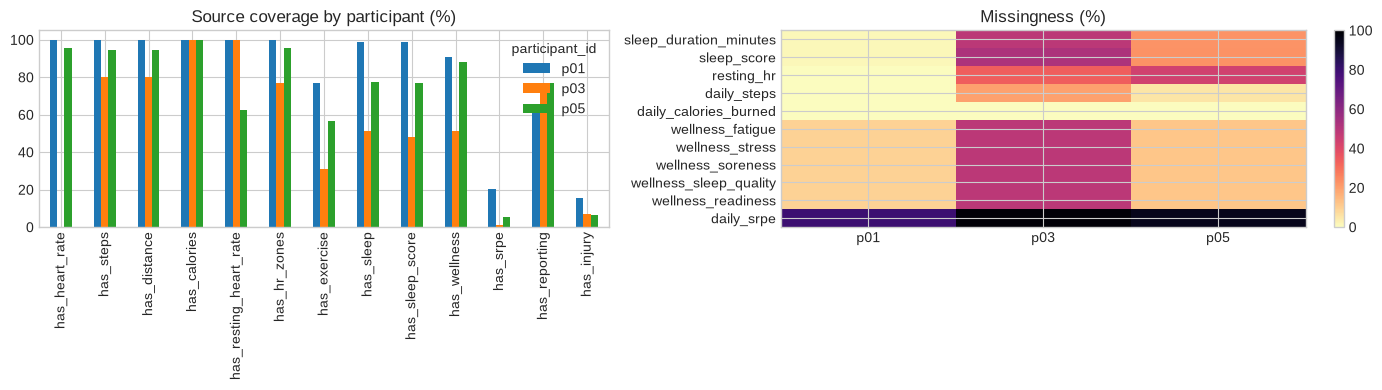

Overall sRPE coverage: 9.0%


In [10]:
availability = [column for column in daily if column.startswith("has_")]
coverage = daily.groupby("participant_id")[availability].mean().mul(100).round(1)
important = ["sleep_duration_minutes", "sleep_score", "resting_hr", "daily_steps",
             "daily_calories_burned", "wellness_fatigue", "wellness_stress",
             "wellness_soreness", "wellness_sleep_quality", "wellness_readiness", "daily_srpe"]
missingness = daily.groupby("participant_id")[important].apply(lambda x: x.isna().mean() * 100).round(1)
display(coverage)
display(missingness)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
coverage.T.plot.bar(ax=axes[0], title="Source coverage by participant (%)")
image = axes[1].imshow(missingness.T, aspect="auto", cmap="magma_r", vmin=0, vmax=100)
axes[1].set(xticks=range(3), xticklabels=missingness.index,
            yticks=range(len(important)), yticklabels=important, title="Missingness (%)")
fig.colorbar(image, ax=axes[1], fraction=.03)
fig.tight_layout(); plt.show()
print("Overall sRPE coverage:", f"{100*daily.has_srpe.mean():.1f}%")

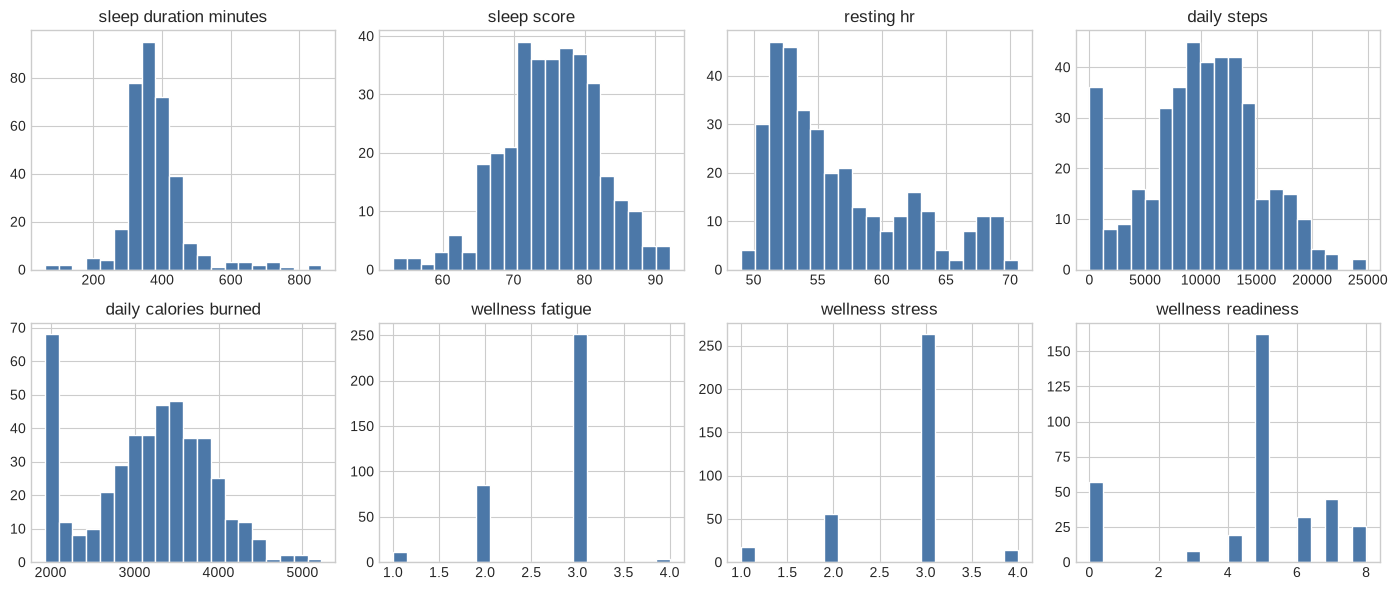

,reports,positives,explicit_negatives
participant_id,,,
p01,24,1,23
p03,11,0,11
p05,10,10,0


participant_id  location  
p01             right_hand    1
p05             head_neck     1
                left_foot     9
Name: reports, dtype: int64

In [11]:
plot_columns = ["sleep_duration_minutes", "sleep_score", "resting_hr", "daily_steps",
                "daily_calories_burned", "wellness_fatigue", "wellness_stress", "wellness_readiness"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for axis, column in zip(axes.flat, plot_columns):
    axis.hist(daily[column].dropna(), bins=20, color="#4C78A8", edgecolor="white")
    axis.set_title(column.replace("_", " "))
fig.tight_layout(); plt.show()

report_behavior = injury_reports.groupby("participant_id").agg(
    reports=("has_any_injury", "size"), positives=("has_any_injury", "sum"))    
report_behavior["explicit_negatives"] = report_behavior["reports"] - report_behavior["positives"]
location_counts = (injury_reports.loc[injury_reports.has_any_injury, ["participant_id", "injuries"]]
                   .assign(location=lambda x: x.injuries.map(lambda value: list(value)))
                   .explode("location").groupby(["participant_id", "location"]).size().rename("reports"))
display(report_behavior)
display(location_counts)

## Future seven-day injury-report targets

For day *t*, the report-aware target examines *t+1* through *t+7*: positive if any questionnaire is positive, negative only if at least one explicit `{}` report exists and none is positive, otherwise unknown. The dense sensitivity label treats every eligible day without a future positive report as negative. Repeated same-location positives remain one episode until an explicit negative report, but that episode label is only a sensitivity diagnostic.

In [12]:
episode_starts = defaultdict(set)
for participant, group in injury_reports.groupby("participant_id"):
    active_locations = set()
    for row in group.itertuples():
        if not row.has_any_injury:
            active_locations.clear()
        else:
            for location in row.injuries:
                if location not in active_locations:
                    episode_starts[participant].add(row.report_date)
                    active_locations.add(location)

primary, dense, episode = [], [], []
for row in daily.itertuples():
    current_date = pd.Timestamp(row.date)
    last_day = daily.loc[daily.participant_id.eq(row.participant_id), "date"].max()
    if current_date + pd.offsets.Day(INJURY_HORIZON) > last_day:
        primary.append(np.nan); dense.append(np.nan); episode.append(np.nan); continue
    window_end = current_date + pd.offsets.Day(INJURY_HORIZON)
    future = injury_reports[(injury_reports.participant_id == row.participant_id) &
                            (injury_reports.report_date > row.date) &
                            (injury_reports.report_date <= window_end)]
    positive, negative = future.has_any_injury.any(), (~future.has_any_injury).any()
    primary.append(1.0 if positive else (0.0 if negative else np.nan))
    dense.append(float(positive))
    episode.append(float(any(row.date < date <= window_end for date in episode_starts[row.participant_id])))

daily["injury_report_positive_next_7d_observed"] = primary
daily["positive_report_next_7d"] = dense
daily["new_episode_next_7d"] = episode
balance_rows = []
for target in ["injury_report_positive_next_7d_observed", "positive_report_next_7d", "new_episode_next_7d"]:
    for participant, frame in [("overall", daily)] + list(daily.groupby("participant_id")):
        labels = frame[target].dropna()
        balance_rows.append({"target": target, "participant": participant, "eligible": len(labels),
                             "positive": int(labels.sum()), "negative": int(len(labels)-labels.sum()),
                             "positive_pct": 100*labels.mean()})
target_balance = pd.DataFrame(balance_rows)
display(target_balance)

,target,participant,eligible,positive,negative,positive_pct
0,injury_report_positive_next_7d_observed,overall,254,57,197,22.440945
1,injury_report_positive_next_7d_observed,p01,133,7,126,5.263158
2,injury_report_positive_next_7d_observed,p03,71,0,71,0.000000
3,injury_report_positive_next_7d_observed,p05,50,50,0,100.000000
4,positive_report_next_7d,overall,435,57,378,13.103448
5,positive_report_next_7d,p01,145,7,138,4.827586
6,positive_report_next_7d,p03,145,0,145,0.000000
7,positive_report_next_7d,p05,145,50,95,34.482759
8,new_episode_next_7d,overall,435,13,422,2.988506
9,new_episode_next_7d,p01,145,7,138,4.827586


## Temporal modeling setup

Evaluation uses three expanding chronological folds. Injury folds have a seven-day embargo, so training labels cannot look into validation. Rolling features use only the current and past days; personalized baselines use `shift(1)`. Imputation and scaling are learned inside each training fold. Participant ID is used only for grouping, fold-local imputation and the explicit confounding diagnostic—not as a physiological model feature.

In [13]:
grouped = daily.groupby("participant_id", sort=False)
rolling = {"sleep_duration_minutes": "sleep", "wellness_fatigue": "fatigue",
           "wellness_stress": "stress", "wellness_soreness": "soreness",
           "daily_steps": "steps", "daily_calories_burned": "calories",
           "exercise_duration_min": "exercise_duration"}
for source, short in rolling.items():
    daily[f"{short}_3d_mean"] = grouped[source].transform(lambda s: s.rolling(3, min_periods=2).mean())
    daily[f"{short}_7d_mean"] = grouped[source].transform(lambda s: s.rolling(7, min_periods=3).mean())
daily["resting_hr_trailing14_baseline"] = grouped.resting_hr.transform(lambda s: s.shift(1).rolling(14, min_periods=7).median())
daily["resting_hr_vs_trailing14"] = daily.resting_hr - daily.resting_hr_trailing14_baseline

def fold_data(frame, train_end, validation_start, validation_end, target):
    train = frame[frame.date.between(pd.Timestamp("2019-11-01"), pd.Timestamp(train_end)) & frame[target].notna()].copy()
    valid = frame[frame.date.between(pd.Timestamp(validation_start), pd.Timestamp(validation_end)) & frame[target].notna()].copy()
    return train, valid

def impute_fold(train, valid, features):
    train_x, valid_x = train[features].copy(), valid[features].copy()
    indicators = [column for column in features if train_x[column].isna().any()]
    participant_medians = train.assign(_participant=train.participant_id).groupby("_participant")[features].median()
    global_median = train_x.median().fillna(0)
    for participant in train.participant_id.unique():
        mask = train.participant_id.eq(participant).to_numpy()
        train_x.loc[mask] = train_x.loc[mask].fillna(participant_medians.loc[participant].fillna(global_median))
    for participant in valid.participant_id.unique():
        mask = valid.participant_id.eq(participant).to_numpy()
        medians = participant_medians.loc[participant] if participant in participant_medians.index else global_median
        valid_x.loc[mask] = valid_x.loc[mask].fillna(medians.fillna(global_median))
    train_x, valid_x = train_x.fillna(global_median), valid_x.fillna(global_median)
    for column in indicators:
        train_x[f"{column}__missing"] = train[column].isna().astype(float).to_numpy()
        valid_x[f"{column}__missing"] = valid[column].isna().astype(float).to_numpy()
    return train_x, valid_x

def classification_metrics(y_true, probability):
    prediction = (np.asarray(probability) >= .5).astype(int)
    return {"precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "f1": f1_score(y_true, prediction, zero_division=0),
            "pr_auc": average_precision_score(y_true, probability) if np.sum(y_true) else np.nan,
            "roc_auc": roc_auc_score(y_true, probability) if len(np.unique(y_true)) == 2 else np.nan}

In [14]:
injury_features = ["sleep_score", "sleep_duration_minutes", "wellness_fatigue", "wellness_mood",
    "wellness_readiness", "wellness_sleep_duration_h", "wellness_sleep_quality", "wellness_soreness",
    "wellness_stress", "resting_hr", "resting_hr_vs_trailing14", "daily_steps", "daily_calories_burned",
    "hr_zone_in_default_zone_1_minutes", "hr_zone_in_default_zone_2_minutes",
    "hr_zone_in_default_zone_3_minutes", "exercise_session_count", "exercise_duration_min",
    "exercise_calories", "sleep_3d_mean", "fatigue_3d_mean", "stress_3d_mean", "soreness_3d_mean",
    "steps_7d_mean", "calories_7d_mean", "exercise_duration_7d_mean"]
injury_folds = [("fold_1", "2019-12-15", "2019-12-23", "2020-01-15"),
                ("fold_2", "2020-01-15", "2020-01-23", "2020-02-15"),
                ("fold_3", "2020-02-15", "2020-02-23", "2020-03-23")]
targets = {"report_aware": "injury_report_positive_next_7d_observed", "dense": "positive_report_next_7d"}
injury_metrics, fold_counts = [], []
for target_name, target in targets.items():
    for fold_name, train_end, valid_start, valid_end in injury_folds:
        train, valid = fold_data(daily, train_end, valid_start, valid_end, target)
        train_y, valid_y = train[target].astype(int), valid[target].astype(int)
        fold_counts.append({"target": target_name, "fold": fold_name, "train_n": len(train),
                            "train_positive": int(train_y.sum()), "valid_n": len(valid),
                            "valid_positive": int(valid_y.sum())})
        if train_y.nunique() < 2 or valid_y.sum() == 0:
            continue
        train_x, valid_x = impute_fold(train, valid, injury_features)
        prevalence = train_y.mean()
        probabilities = {"prevalence_baseline": np.full(len(valid), prevalence)}
        rates = train.assign(label=train_y).groupby("participant_id").label.mean()
        probabilities["participant_prevalence"] = valid.participant_id.map(rates).fillna(prevalence).to_numpy()

        scaler = StandardScaler().fit(train_x)
        logistic = LogisticRegression(C=.5, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
        logistic.fit(scaler.transform(train_x), train_y)
        probabilities["logistic_regression"] = logistic.predict_proba(scaler.transform(valid_x))[:, 1]

        positives, negatives = int(train_y.sum()), int((1-train_y).sum())
        xgb = XGBClassifier(n_estimators=80, max_depth=2, learning_rate=.05, min_child_weight=3,
            subsample=.8, colsample_bytree=.8, reg_alpha=.2, reg_lambda=5,
            scale_pos_weight=negatives/max(positives, 1), eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=1)
        xgb.fit(train_x, train_y)
        probabilities["xgboost"] = xgb.predict_proba(valid_x)[:, 1]
        for model, probability in probabilities.items():
            injury_metrics.append({"target": target_name, "fold": fold_name, "model": model,
                                   **classification_metrics(valid_y, probability)})

fold_counts = pd.DataFrame(fold_counts)
injury_fold_metrics = pd.DataFrame(injury_metrics)
injury_results = injury_fold_metrics.groupby(["target", "model"], as_index=False).agg(
    folds=("fold", "nunique"), precision=("precision", "mean"), recall=("recall", "mean"),
    f1=("f1", "mean"), pr_auc=("pr_auc", "mean"), roc_auc=("roc_auc", "mean"))
display(fold_counts)
display(injury_results.round(3))

,target,fold,train_n,train_positive,valid_n,valid_positive
0,report_aware,fold_1,65,6,40,7
1,report_aware,fold_2,115,13,61,21
2,report_aware,fold_3,190,34,55,22
3,dense,fold_1,135,6,72,7
4,dense,fold_2,228,13,72,21
5,dense,fold_3,321,34,90,22


,target,model,folds,precision,recall,f1,pr_auc,roc_auc
0,dense,logistic_regression,3,0.311,0.307,0.297,0.389,0.744
1,dense,participant_prevalence,3,0.000,0.000,0.000,0.423,0.586
2,dense,prevalence_baseline,3,0.000,0.000,0.000,0.211,0.500
3,dense,xgboost,3,0.302,0.092,0.141,0.396,0.708
4,report_aware,logistic_regression,3,0.394,0.304,0.318,0.450,0.570
5,report_aware,participant_prevalence,3,0.667,0.667,0.667,0.725,0.833
6,report_aware,prevalence_baseline,3,0.000,0.000,0.000,0.306,0.500
7,report_aware,xgboost,3,0.643,0.509,0.552,0.571,0.685


The report-aware definition avoids calling unobserved status negative, but its eligible rows are severely participant-selected: p03 has no positives and p05's eligible rows are all positive. The participant-prevalence diagnostic therefore performs extremely well. The dense label supplies more rows only by making the stronger assumption that intermittent non-reporting is negative. Neither result supports a generalizable clinical injury model; these are **positive injury-report proxies**.

## Wellness-derived Performance Readiness Index

The Hooper-inspired PRI uses sleep quality, fatigue, stress and soreness. In this dataset all four scales run from 1 (bad) to 5 (good), so each component is `(value - 1) / 4`. PRI is their mean times 100 and requires all four. The separate 0–10 readiness response is not part of PRI; it is used only as an independent sanity check. This custom proxy is not a validated objective performance measure.

count    350.00000
mean      44.25000
std        8.77376
min       12.50000
25%       37.50000
50%       50.00000
75%       50.00000
max       75.00000
Name: performance_readiness_index, dtype: float64

,participant,n,pearson,spearman
0,overall,350,0.354,0.242
1,p01,138,0.578,0.604
2,p03,78,0.331,0.242
3,p05,134,0.550,0.557


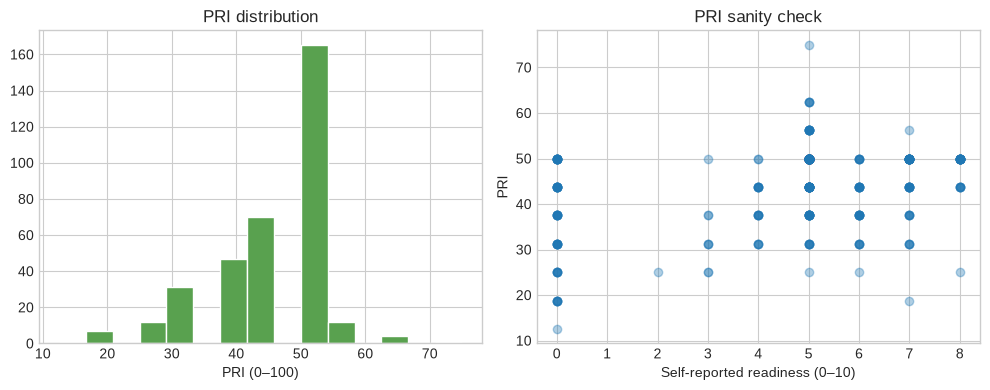

In [15]:
pri_components = ["wellness_sleep_quality", "wellness_fatigue", "wellness_stress", "wellness_soreness"]
valid_pri = daily[pri_components].notna().all(axis=1)
daily["performance_readiness_index"] = np.where(
    valid_pri, 100 * daily[pri_components].sub(1).div(4).mean(axis=1), np.nan)
daily["next_day_performance_readiness_index"] = daily.groupby("participant_id").performance_readiness_index.shift(-1)
daily["sleep_trailing14_baseline"] = daily.groupby("participant_id").sleep_duration_minutes.transform(
    lambda s: s.shift(1).rolling(14, min_periods=7).median())
daily["sleep_vs_trailing14"] = daily.sleep_duration_minutes - daily.sleep_trailing14_baseline

correlations = []
for participant, frame in [("overall", daily)] + list(daily.groupby("participant_id")):
    paired = frame[["performance_readiness_index", "wellness_readiness"]].dropna()
    correlations.append({"participant": participant, "n": len(paired),
                         "pearson": stats.pearsonr(*paired.to_numpy().T).statistic,
                         "spearman": stats.spearmanr(*paired.to_numpy().T).statistic})
correlations = pd.DataFrame(correlations)
display(daily.performance_readiness_index.describe())
display(correlations.round(3))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(daily.performance_readiness_index.dropna(), bins=15, color="#59A14F", edgecolor="white")
axes[0].set(title="PRI distribution", xlabel="PRI (0–100)")
axes[1].scatter(daily.wellness_readiness, daily.performance_readiness_index, alpha=.35)
axes[1].set(title="PRI sanity check", xlabel="Self-reported readiness (0–10)", ylabel="PRI")
fig.tight_layout(); plt.show()

## Next-day PRI prediction

Features available by the end of day *t* predict PRI on *t+1*. No *t+1* wellness component appears in the predictors. The comparison is deliberately modest: persistence (`tomorrow ≈ today`), Ridge and a small regularized XGBoost regressor, evaluated on expanding temporal folds.

In [16]:
performance_features = ["performance_readiness_index", "sleep_score", "sleep_duration_minutes", "resting_hr",
    "resting_hr_vs_trailing14", "sleep_vs_trailing14", "daily_steps", "daily_calories_burned",
    "exercise_duration_min", "exercise_calories", "wellness_mood", "wellness_readiness", "sleep_3d_mean",
    "fatigue_3d_mean", "stress_3d_mean", "soreness_3d_mean", "steps_7d_mean", "calories_7d_mean",
    "exercise_duration_7d_mean"]
performance_folds = [("fold_1", "2019-12-15", "2019-12-17", "2020-01-15"),
                     ("fold_2", "2020-01-15", "2020-01-17", "2020-02-15"),
                     ("fold_3", "2020-02-15", "2020-02-17", "2020-03-23")]
performance_metrics = []
for fold_name, train_end, valid_start, valid_end in performance_folds:
    usable = daily.next_day_performance_readiness_index.notna() & daily.performance_readiness_index.notna()
    train = daily[usable & daily.date.between(pd.Timestamp("2019-11-01"), pd.Timestamp(train_end))].copy()
    valid = daily[usable & daily.date.between(pd.Timestamp(valid_start), pd.Timestamp(valid_end))].copy()
    train_x, valid_x = impute_fold(train, valid, performance_features)
    train_y, valid_y = train.next_day_performance_readiness_index, valid.next_day_performance_readiness_index
    scaler = StandardScaler().fit(train_x)
    ridge = Ridge(alpha=10).fit(scaler.transform(train_x), train_y)
    xgb = XGBRegressor(n_estimators=100, max_depth=2, learning_rate=.04, min_child_weight=4,
        subsample=.8, colsample_bytree=.8, reg_alpha=.2, reg_lambda=5,
        objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=1).fit(train_x, train_y)
    predictions = {"persistence": valid.performance_readiness_index.to_numpy(),
                   "ridge": ridge.predict(scaler.transform(valid_x)), "xgboost": xgb.predict(valid_x)}
    for model, prediction in predictions.items():
        performance_metrics.append({"fold": fold_name, "model": model,
            "mae": mean_absolute_error(valid_y, prediction),
            "rmse": mean_squared_error(valid_y, prediction) ** .5,
            "r2": r2_score(valid_y, prediction)})
performance_fold_metrics = pd.DataFrame(performance_metrics)
performance_results = performance_fold_metrics.groupby("model", as_index=False).agg(
    folds=("fold", "nunique"), mae=("mae", "mean"), rmse=("rmse", "mean"), r2=("r2", "mean"))
display(performance_fold_metrics.round(3))
display(performance_results.round(3))
print("Lowest mean MAE:", performance_results.loc[performance_results.mae.idxmin(), "model"])

,fold,model,mae,rmse,r2
0,fold_1,persistence,4.741,7.431,0.090
1,fold_1,ridge,7.524,9.398,-0.456
2,fold_1,xgboost,6.554,8.407,-0.165
3,fold_2,persistence,6.052,8.874,-0.458
4,fold_2,ridge,5.029,6.541,0.208
5,fold_2,xgboost,5.380,6.978,0.098
6,fold_3,persistence,5.000,8.069,0.027
7,fold_3,ridge,5.620,6.956,0.277
8,fold_3,xgboost,4.967,6.837,0.301


,model,folds,mae,rmse,r2
0,persistence,3,5.264,8.125,-0.114
1,ridge,3,6.058,7.632,0.009
2,xgboost,3,5.634,7.407,0.078


Lowest mean MAE: persistence


Persistence has the best mean MAE: readiness changes slowly enough that today's PRI is a hard baseline to beat. On this small sample the learned models do not demonstrate useful incremental value, and no tuning is used to force a different conclusion.

## Food-image metadata and approximate nutrition

Pillow reads metadata only; images are not copied or displayed. `DateTimeOriginal` is preferred, then `DateTimeDigitized` and `DateTime`. Normal execution loads the committed per-image VLM results, so it never launches hundreds of API requests. Provider/model provenance remains per image because two Gemini Flash-Lite versions were used after a free-tier quota limit.

In [17]:
image_rows = []
for participant in participants:
    image_dir = RAW_DIR / participant / "food-images"
    for path in sorted(p for p in image_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}):
        with Image.open(path) as image:
            exif = image.getexif()
            try:
                exif_ifd = exif.get_ifd(ExifTags.IFD.Exif)
            except Exception:
                exif_ifd = {}
            values = [("DateTimeOriginal", exif_ifd.get(36867)),
                      ("DateTimeDigitized", exif_ifd.get(36868)), ("DateTime", exif.get(306))]
            source, raw_timestamp = next(((name, value) for name, value in values if value), ("missing", None))
            timestamp = pd.to_datetime(raw_timestamp, format="%Y:%m:%d %H:%M:%S", errors="coerce")
            image_rows.append({"participant_id": participant, "filename": path.name,
                               "capture_timestamp": timestamp, "date": timestamp.normalize() if pd.notna(timestamp) else pd.NaT,
                               "timestamp_source": source, "width": image.width, "height": image.height})
image_metadata = pd.DataFrame(image_rows)
food_image_daily = image_metadata.dropna(subset=["date"]).groupby(["participant_id", "date"], as_index=False).size()
food_image_daily = food_image_daily.rename(columns={"size": "food_image_count"})
print(f"Images: {len(image_metadata)}; usable timestamps: {image_metadata.date.notna().sum()}; days: {len(food_image_daily)}")
display(food_image_daily.groupby("participant_id").agg(images=("food_image_count", "sum"), days=("date", "size")))

if RUN_VLM:
    raise RuntimeError("VLM inference is intentionally explicit; use the documented optional command after setting GEMINI_API_KEY.")
if not NUTRITION_RESULTS.exists():
    raise FileNotFoundError("Cached per-image estimates are missing. See the README for the optional VLM step.")
per_image = pd.read_csv(NUTRITION_RESULTS)
per_image["date"] = pd.to_datetime(per_image["date"])
adjustments = pd.read_csv(ALCOHOL_ADJUSTMENTS)
assert len(per_image) == len(image_metadata) == 643
assert not per_image.duplicated(["participant_id", "filename"]).any()

usable = per_image[per_image.status.eq("success")]
counts = per_image.groupby(["participant_id", "date"]).status.agg(
    nutrition_recorded_image_count="size", nutrition_successful_image_count=lambda s: s.eq("success").sum(),
    nutrition_flagged_image_count=lambda s: s.eq("flagged").sum(),
    nutrition_error_image_count=lambda s: s.eq("error").sum(),
    nutrition_failed_image_count=lambda s: s.ne("success").sum()).reset_index()
nutrients = usable.groupby(["participant_id", "date"], as_index=False).agg(
    nutrition_estimated_calories_kcal=("estimated_calories_kcal", "sum"),
    nutrition_estimated_protein_g=("estimated_protein_g", "sum"),
    nutrition_estimated_carbs_g=("estimated_carbs_g", "sum"),
    nutrition_estimated_fat_g=("estimated_fat_g", "sum"))
nutrition_daily = counts.merge(nutrients, on=["participant_id", "date"], how="left")
nutrition_daily["nutrition_complete_for_recorded_images"] = (
    nutrition_daily.nutrition_failed_image_count.eq(0)).astype("int8")
print(per_image.status.value_counts().to_dict())
print("Nutrition participant-days / complete recorded-image days:", len(nutrition_daily),
      int(nutrition_daily.nutrition_complete_for_recorded_images.sum()))
display(adjustments[["participant_id", "filename", "beverage_label", "adjustment_applied",
                     "estimated_alcohol_g", "alcohol_energy_kcal", "decision_note"]])

Images: 643; usable timestamps: 643; days: 158


,images,days
participant_id,,
p01,321,60
p03,136,51
p05,186,47


{'success': 634, 'flagged': 9}
Nutrition participant-days / complete recorded-image days: 158 150


,participant_id,filename,beverage_label,adjustment_applied,estimated_alcohol_g,alcohol_energy_kcal,decision_note
0,p01,IMG_9006.jpeg,Red wine,True,14.79375,103.55625,Applied 7 kcal/g ethanol using the existing portion as approximate mL; ABV and volume remain uncertain.
1,p01,IMG_9164.jpeg,red wine,True,14.79375,103.55625,Applied 7 kcal/g ethanol using the existing portion as approximate mL; ABV and volume remain uncertain.
2,p03,IMG_2645.jpg,red wine,True,14.79375,103.55625,Applied 7 kcal/g ethanol using the existing portion as approximate mL; ABV and volume remain uncertain.
3,p03,IMG_2649.jpg,Red wine,True,14.79375,103.55625,Applied 7 kcal/g ethanol using the existing portion as approximate mL; ABV and volume remain uncertain.
4,p03,IMG_2732.jpg,red wine,True,14.79375,103.55625,Applied 7 kcal/g ethanol using the existing portion as approximate mL; ABV and volume remain uncertain.
5,p05,IMG_2398.jpg,beer,True,13.80750,96.65250,Applied 7 kcal/g ethanol using the existing portion as approximate mL; ABV and volume remain uncertain.
6,p05,281dad76-7501-4f0c-b81b-92fdeb256ab3.jpg,Red wine or grape juice,False,NaN,0.00000,"No ethanol energy added because the beverage identity is ambiguous, the portion is unavailable, or the estimate is not usable."


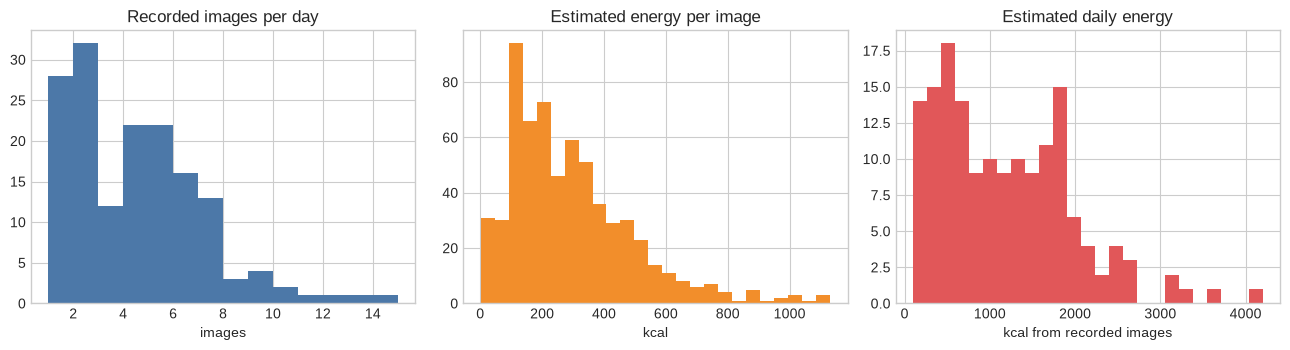

Six clear alcohol images were adjusted; one wine-or-grape-juice image remains unadjusted and uncertain.
Complete means every recorded image that day was processed—not that every consumed item was photographed.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(food_image_daily.food_image_count, bins=range(1, int(food_image_daily.food_image_count.max())+2), color="#4C78A8")
axes[0].set(title="Recorded images per day", xlabel="images")
axes[1].hist(usable.estimated_calories_kcal, bins=25, color="#F28E2B")
axes[1].set(title="Estimated energy per image", xlabel="kcal")
axes[2].hist(nutrition_daily.nutrition_estimated_calories_kcal, bins=25, color="#E15759")
axes[2].set(title="Estimated daily energy", xlabel="kcal from recorded images")
fig.tight_layout(); plt.show()
print("Six clear alcohol images were adjusted; one wine-or-grape-juice image remains unadjusted and uncertain.")
print("Complete means every recorded image that day was processed—not that every consumed item was photographed.")

## Final participant-day dataset

Nutrition estimates are left-joined by participant and date and remain optional. They are not used in the primary injury or PRI models because food images cover only part of February–March. The simplified dataset intentionally omits some redundant audit/internal fields from the 146-column reference table.

In [19]:
daily = daily.merge(food_image_daily, on=["participant_id", "date"], how="left", validate="one_to_one")
daily = daily.merge(nutrition_daily, on=["participant_id", "date"], how="left", validate="one_to_one")
daily["has_food_images"] = daily.food_image_count.notna().astype("int8")
daily["nutrition_estimation_available"] = daily.nutrition_successful_image_count.fillna(0).gt(0).astype("int8")

assert (daily.shape[0] == 456 and not daily.duplicated(["participant_id", "date"]).any()
        and daily.date.min() == pd.Timestamp("2019-11-01") and daily.date.max() == pd.Timestamp("2020-03-31"))
daily.to_csv(ROOT / "test_dataset.csv", index=False, date_format="%Y-%m-%d")
print(f"Wrote test_dataset.csv | final shape: {daily.shape}")

Wrote test_dataset.csv | final shape: (456, 129)


## Conclusions and limitations

- Coverage is heterogeneous: p03 structurally lacks continuous HR, while resting HR is a separate source.
- sRPE is too sparse for the primary models and can encode participant identity after imputation.
- Injury outcomes are intermittent questionnaires, not clinically verified incident injuries; repeated p05 left-foot reports may be one ongoing episode.
- Injury discrimination is heavily participant-confounded. The learned feature models do not convincingly establish generalizable physiological risk.
- PRI is a literature-inspired wellness proxy, not measured sporting performance; persistence is difficult to beat for next-day PRI.
- Nutrition values are approximate image estimates and depend on which foods were photographed. “Complete” refers only to recorded images.
- Three participants cannot establish generalization to unseen athletes. Predictive association is not causation.

### References

- Thambawita et al. (2020), *PMData: A Sports Logging Dataset*.
- Hooper & Mackinnon (1995), *Monitoring overtraining in athletes. Recommendations*. PMID: 8571005.
- Hooper et al. (1995), *Markers for monitoring overtraining and recovery*. PMID: 7898325.
- Foster et al. (2001), session-RPE method, *Journal of Strength and Conditioning Research*, 15(1), 109–115.